# Drogued drifter in CMEMS Baltic currents

Proof of concept coupling the `DroguedDrifter` model to real CMEMS Baltic Sea currents via Parcels v4. This combines the CMEMS pipeline from notebook 02 with the drogued drifter kernel from notebook 01.

The drifter kernel samples UV at two depths using nearest-neighbor to the CMEMS depth levels (no vertical interpolation). We compare drogued drifter trajectories against surface point particles advected with AdvectionRK4.

This is a pipeline proof of concept, not a validation against observations.

## Imports

In [ ]:
import shutil
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from parcels import FieldSet, Particle, ParticleFile, ParticleSet, StatusCode, Variable
from parcels._core.statuscodes import FieldOutOfBoundError  # private import, parcels v4 alpha
from parcels.kernels import AdvectionRK4

from drogued_drifters.drifter import DroguedDrifter

## Parameters

In [ ]:
N_PARTICLES = 20
LON_MIN = 10.0
LON_MAX = 11.0
LAT_MIN = 54.3
LAT_MAX = 54.6
RANDOM_SEED = 42
DROGUE_DEPTH = 3.0
DT = 300.0
RUNTIME = 172800.0  # 48 hours [s]
OUTPUTDT = 3600.0
CMEMS_DIR = "examples/baltic_drifters/data/cmems"

## Load CMEMS data

Same pipeline as notebook 02: open the CMEMS Baltic Sea physics product lazily, subset to the Kiel Bight, rename velocity components, fill land with zero, and add SGRID topology for Parcels.

In [ ]:
ds_sub = xr.open_dataset(CMEMS_DIR + "/cmems_mod_bal_phy_anfc_PT1H-i.nc").sel(
    longitude=slice(9.5, 11.5),
    latitude=slice(54.0, 55.5),
    time=slice("2023-04-24", "2023-04-27"),
)

ds_sub = ds_sub.rename({"uo": "U", "vo": "V"}).fillna(0.0)

# Add z=0 layer by copying shallowest level (the CMEMS top cell is a
# near-surface average). Without this, sampling at z=0 is out of bounds.
ds_z0 = ds_sub.isel(depth=0).assign_coords(depth=0.0)
ds_sub = xr.concat([ds_z0, ds_sub], dim="depth")

ds_sub = ds_sub.load()
ds_sub

In [ ]:
ds_sub["grid"] = xr.DataArray(
    data=0,
    attrs={
        "cf_role": "grid_topology",
        "topology_dimension": 2,
        "node_dimensions": "longitude latitude",
        "face_dimensions": (
            "longitude:longitude (padding: none) "
            "latitude:latitude (padding: none)"
        ),
        "vertical_dimensions": "depth:depth (padding: none)",
        "node_coordinates": "longitude latitude",
    },
)

fieldset = FieldSet.from_sgrid_conventions(ds_sub, mesh="spherical")
fieldset.add_constant("drogue_depth", DROGUE_DEPTH)

## Drifter kernel

Same coupling strategy as notebook 01: at each Parcels timestep, sample UV at the surface (z=0, snaps to the shallowest CMEMS level at ~0.5 m) and at the drogue depth (z=3.0, snaps to the nearest CMEMS level at ~3.6 m). Feed both velocity pairs to `get_final_drift_batch`, which solves to steady state in one vectorized call. Apply the result as a forward Euler step.

Because the FieldSet uses `mesh="spherical"`, Parcels returns velocities in deg/s (the raw m/s data divided by `1852*60*cos(lat)` for U and `1852*60` for V). The DroguedDrifter model works in Cartesian coordinates (m/s), so the kernel converts deg/s to m/s before calling the model and converts the output back to deg/s before updating dlon/dlat.

The solver is warm-started from the previous steady state. Trajectories are stored in a Python dict because the Parcels v4 alpha zarr writer has a known bug with custom kernels.

In [4]:
DrifterParticle = Particle.add_variable(Variable("z_eff", dtype=np.float64, initial=0.0))

dd = DroguedDrifter()
_warm_state = {}

drifter_trajectory = {"lon": [], "lat": [], "time": []}

# Parcels returns velocities in deg/s on spherical meshes (raw m/s divided
# by 1852*60*cos(lat) for U and 1852*60 for V).  The DroguedDrifter model
# works in Cartesian m/s, so we convert back and forth.
_DEG2M = 1852.0 * 60.0  # meters per degree of latitude


def DroguedDrifterKernel(particles, fieldset):
    """Advect particles at the steady-state drift velocity of a buoy+drogue."""
    drogue_depth = fieldset.drogue_depth

    n = len(np.asarray(particles.lon))
    z_surface = np.zeros(n)
    z_drogue = np.full(n, drogue_depth)
    try:
        (u_b, v_b) = fieldset.UV[
            particles.time, z_surface, particles.lat, particles.lon, particles
        ]
        (u_d, v_d) = fieldset.UV[
            particles.time, z_drogue, particles.lat, particles.lon, particles
        ]
    except FieldOutOfBoundError:
        particles.state = StatusCode.Delete
        return

    u_b, v_b = np.asarray(u_b), np.asarray(v_b)
    u_d, v_d = np.asarray(u_d), np.asarray(v_d)
    dt = np.asarray(particles.dt)
    lon_arr = np.asarray(particles.lon)
    lat_arr = np.asarray(particles.lat)
    time_arr = np.asarray(particles.time)

    # --- deg/s  ->  m/s (for the Cartesian drifter model) ---
    cos_lat = np.cos(np.deg2rad(lat_arr))
    deg2m_lon = _DEG2M * cos_lat  # m per degree of longitude
    u_b_ms = u_b * deg2m_lon
    v_b_ms = v_b * _DEG2M
    u_d_ms = u_d * deg2m_lon
    v_d_ms = v_d * _DEG2M

    n = len(u_b_ms)
    y0_warm = _warm_state.get("Y") if _warm_state.get("n") == n else None
    xd_drift_ms, yd_drift_ms, theta_final, Y_final = dd.get_final_drift_batch(
        U_b=u_b_ms, V_b=v_b_ms, U_d=u_d_ms, V_d=v_d_ms, y0=y0_warm,
    )
    _warm_state["Y"] = Y_final
    _warm_state["n"] = n
    z_eff = -dd.l * np.cos(theta_final)

    # --- m/s  ->  deg/s (back to Parcels spherical convention) ---
    xd_drift = xd_drift_ms / deg2m_lon
    yd_drift = yd_drift_ms / _DEG2M

    particles.dlon += xd_drift * dt
    particles.dlat += yd_drift * dt
    particles.z_eff = z_eff

    drifter_trajectory["lon"].append(lon_arr.copy())
    drifter_trajectory["lat"].append(lat_arr.copy())
    drifter_trajectory["time"].append(time_arr.copy())


def DeleteOOB(particles, fieldset):
    """Convert out-of-bounds errors to Delete status."""
    state = np.asarray(particles.state)
    oob = (state == StatusCode.ErrorOutOfBounds) | (state == StatusCode.ErrorThroughSurface)
    if np.any(oob):
        particles.state = np.where(oob, StatusCode.Delete, state)

## Release particles

20 random positions in the southern Kiel Bight.

In [ ]:
rng = np.random.default_rng(RANDOM_SEED)
release_lons = rng.uniform(LON_MIN, LON_MAX, N_PARTICLES)
release_lats = rng.uniform(LAT_MIN, LAT_MAX, N_PARTICLES)

## Run simulations

Run the drogued drifter kernel and surface point particles (AdvectionRK4 at the shallowest CMEMS depth) for 48 hours with a 5-minute timestep.

Note: the drifter kernel uses forward Euler while point particles use RK4. Both use the same Parcels unit convention (dlon/dlat in the same units as fieldset velocity output).

In [ ]:
SHALLOWEST_DEPTH = float(ds_sub.depth.values[0])

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [7]:
# Drogued drifter run
pset_drifter = ParticleSet(
    fieldset=fieldset,
    pclass=DrifterParticle,
    lon=release_lons.tolist(),
    lat=release_lats.tolist(),
    z=[SHALLOWEST_DEPTH] * N_PARTICLES,
)
pset_drifter.execute(
    kernels=[DroguedDrifterKernel, DeleteOOB],
    dt=DT,
    runtime=RUNTIME,
    verbose_progress=False,
)

  0%|          | 0/172800.0 [00:00<?, ?it/s]

Integration time: 0.0:   0%|          | 0/172800.0 [00:00<?, ?it/s]

Integration time: 2023-04-24T00:00:00.000000000:   0%|          | 0/172800.0 [00:19<?, ?it/s]

Integration time: 2023-04-24T00:00:00.000000000: 100%|██████████| 172800.0/172800.0 [00:19<00:00, 8902.28it/s]

Integration time: 2023-04-24T00:00:00.000000000: 100%|██████████| 172800.0/172800.0 [00:19<00:00, 8902.10it/s]

In [8]:
# Surface point particle run
surface_store = str(OUTPUT_DIR / "cmems_surface.zarr")
shutil.rmtree(surface_store, ignore_errors=True)

pset_surface = ParticleSet(
    fieldset=fieldset,
    pclass=Particle,
    lon=release_lons.tolist(),
    lat=release_lats.tolist(),
    z=[SHALLOWEST_DEPTH] * N_PARTICLES,
)
pset_surface.execute(
    kernels=[AdvectionRK4, DeleteOOB],
    dt=DT,
    runtime=RUNTIME,
    output_file=ParticleFile(store=surface_store, outputdt=OUTPUTDT),
    verbose_progress=False,
)

INFO: Output files are stored in /Users/wrath/src/github.com/geomar-od-lagrange/2025_drogued_drifters/output/cmems_surface.zarr


  0%|          | 0/172800.0 [00:00<?, ?it/s]

Integration time: 0.0:   0%|          | 0/172800.0 [00:00<?, ?it/s]

Integration time: 2023-04-24T00:00:00.000000000:   0%|          | 0/172800.0 [00:00<?, ?it/s]

Integration time: 2023-04-24T00:00:00.000000000:   0%|          | 0.0/172800.0 [00:00<?, ?it/s]

...

Integration time: 2023-04-25T21:00:00.000000000:  94%|█████████▍| 162000.0/172800.0 [00:02<00:00, 66308.65it/s]

Integration time: 2023-04-25T22:00:00.000000000:  96%|█████████▌| 165600.0/172800.0 [00:02<00:00, 66308.65it/s]

Integration time: 2023-04-25T22:00:00.000000000:  98%|█████████▊| 169200.0/172800.0 [00:02<00:00, 67542.01it/s]

Integration time: 2023-04-25T23:00:00.000000000:  98%|█████████▊| 169200.0/172800.0 [00:02<00:00, 67542.01it/s]

Integration time: 2023-04-25T23:00:00.000000000: 100%|██████████| 172800.0/172800.0 [00:02<00:00, 67296.37it/s]

In [9]:
# 3m point particle run
DROGUE_DEPTH_LEVEL = float(ds_sub.depth.sel(depth=3.0, method="nearest"))

drogue_store = str(OUTPUT_DIR / "cmems_drogue.zarr")
shutil.rmtree(drogue_store, ignore_errors=True)

pset_drogue = ParticleSet(
    fieldset=fieldset,
    pclass=Particle,
    lon=release_lons.tolist(),
    lat=release_lats.tolist(),
    z=[DROGUE_DEPTH_LEVEL] * N_PARTICLES,
)
pset_drogue.execute(
    kernels=[AdvectionRK4, DeleteOOB],
    dt=DT,
    runtime=RUNTIME,
    output_file=ParticleFile(store=drogue_store, outputdt=OUTPUTDT),
    verbose_progress=False,
)

INFO: Output files are stored in /Users/wrath/src/github.com/geomar-od-lagrange/2025_drogued_drifters/output/cmems_drogue.zarr


  0%|          | 0/172800.0 [00:00<?, ?it/s]

Integration time: 0.0:   0%|          | 0/172800.0 [00:00<?, ?it/s]

Integration time: 2023-04-24T00:00:00.000000000:   0%|          | 0/172800.0 [00:00<?, ?it/s]

Integration time: 2023-04-24T00:00:00.000000000:   0%|          | 0.0/172800.0 [00:00<?, ?it/s]

...

Integration time: 2023-04-25T21:00:00.000000000:  96%|█████████▌| 165600.0/172800.0 [00:02<00:00, 71360.92it/s]

Integration time: 2023-04-25T22:00:00.000000000:  96%|█████████▌| 165600.0/172800.0 [00:02<00:00, 71360.92it/s]

Integration time: 2023-04-25T23:00:00.000000000:  98%|█████████▊| 169200.0/172800.0 [00:02<00:00, 71360.92it/s]

Integration time: 2023-04-25T23:00:00.000000000: 100%|██████████| 172800.0/172800.0 [00:02<00:00, 71062.97it/s]

Integration time: 2023-04-25T23:00:00.000000000: 100%|██████████| 172800.0/172800.0 [00:02<00:00, 70135.25it/s]

## Plot trajectories

Surface point particles (red), 3m point particles (green), drogued drifters (blue, dashed).

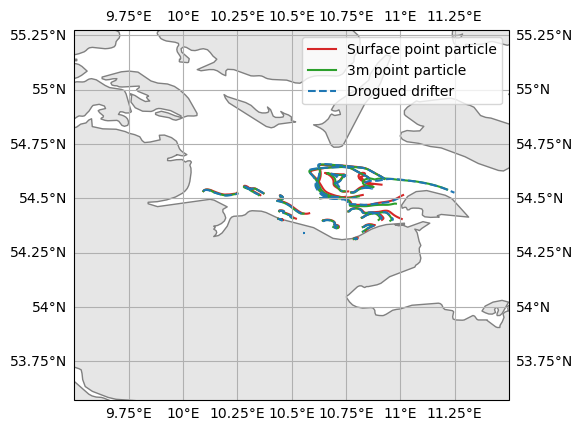

In [10]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})

# Surface point particles
ds_surface = xr.open_zarr(surface_store)
for i in range(ds_surface.sizes["trajectory"]):
    lon_i = ds_surface.lon.values[i, :]
    lat_i = ds_surface.lat.values[i, :]
    valid = np.isfinite(lon_i)
    ax.plot(lon_i[valid], lat_i[valid], color="tab:red",
            label="Surface point particle" if i == 0 else None)

# 3m point particles
ds_drogue = xr.open_zarr(drogue_store)
for i in range(ds_drogue.sizes["trajectory"]):
    lon_i = ds_drogue.lon.values[i, :]
    lat_i = ds_drogue.lat.values[i, :]
    valid = np.isfinite(lon_i)
    ax.plot(lon_i[valid], lat_i[valid], color="tab:green",
            label=f"3m point particle" if i == 0 else None)

# Drogued drifters from trajectory dict
if drifter_trajectory["lon"]:
    n0 = len(drifter_trajectory["lon"][0])
    full_steps = [i for i, arr in enumerate(drifter_trajectory["lon"]) if len(arr) == n0]
    if full_steps:
        d_lon = np.array([drifter_trajectory["lon"][i] for i in full_steps])
        d_lat = np.array([drifter_trajectory["lat"][i] for i in full_steps])
        for i in range(n0):
            ax.plot(d_lon[:, i], d_lat[:, i], color="tab:blue", ls="--",
                    label="Drogued drifter" if i == 0 else None)

land = cfeature.NaturalEarthFeature("physical", "land", "10m",
                                     facecolor="0.9", edgecolor="0.5")
ax.add_feature(land)
ax.set_extent([9.5, 11.5, 53.8, 55.5])
ax.gridlines(draw_labels=True)
ax.legend()
plt.show()